Обработка кардиологических наборов данных для решения задач бинарной классификации.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from flaml import AutoML

1. Загрузка и обработка набора данных
Загружаем набор данных, содержащий признаки ЭКГ, ограничивая количество строк до 5000 для ускорения обработки.
Выполняем предварительную обработку данных и проектирование признаков.

In [2]:
# 加载数据 (nrows=5000)
file_path = 'модуль 3 - датасет - практика.csv'
try:
    df = pd.read_csv(file_path, nrows=5000)
except UnicodeDecodeError:
    df = pd.read_csv(file_path, nrows=5000, encoding='cp1251')

# 数据预处理
core_features = ['rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']

# 处理异常值
for col in core_features:
    df[col] = df[col].replace(29999, np.nan)
    df[col] = df[col].fillna(df[col].median())

# 特征工程 (保持关键衍生指标)
df['pr_interval'] = df['qrs_onset'] - df['p_onset']
df['qrs_duration'] = df['qrs_end'] - df['qrs_onset']
df['qt_interval'] = df['t_end'] - df['qrs_onset']

final_features = core_features + ['pr_interval', 'qrs_duration', 'qt_interval']
X = df[final_features]
y = df['Healthy_Status']

2. Разделение на выборки и стандартизация
Разделяем данные на обучающую и тестовую выборки с сохранением баланса классов, затем выполняем стандартизацию признаков.

In [3]:
# 划分与标准化
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 转回 DataFrame
X_train_df = pd.DataFrame(X_train_scaled, columns=final_features)
X_test_df = pd.DataFrame(X_test_scaled, columns=final_features)

3. Автоматический подбор модели с помощью AutoML (FLAML)
Запускаем автоматический поиск лучших моделей (LGBM, XGBoost, RandomForest).

In [4]:
# AutoML 深度搜索配置
automl = AutoML()
automl_settings = {
    "time_budget": 120,            # 120秒搜索
    "metric": 'f1',                # 核心优化 F1
    "task": 'classification',
    "estimator_list": ['lgbm', 'xgboost', 'rf'],
    "split_ratio": 0.1,            # 内部验证集比例
    "seed": 42,
    "verbose": 0
}

print("Запуск AutoML (обработка 5000 строк):")
automl.fit(X_train=X_train_df, y_train=y_train.values, **automl_settings)

Запуск AutoML (обработка 5000 строк):


4. Оценка качества модели и визуализация результатов
Выполняем прогнозирование на тестовом наборе данных и оцениваем его качество с помощью показателя F1.
Строим матрицу ошибок для анализа точности классификации здоровых/больных пациентов.
Уменьшаем размерность признаков до 2D для визуальной оценки разделимости классов.

Лучшая модель: lgbm
F1 на тесте: 0.8630


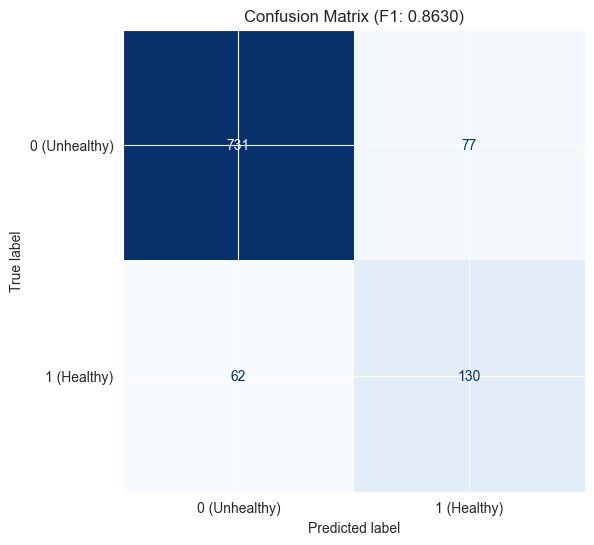

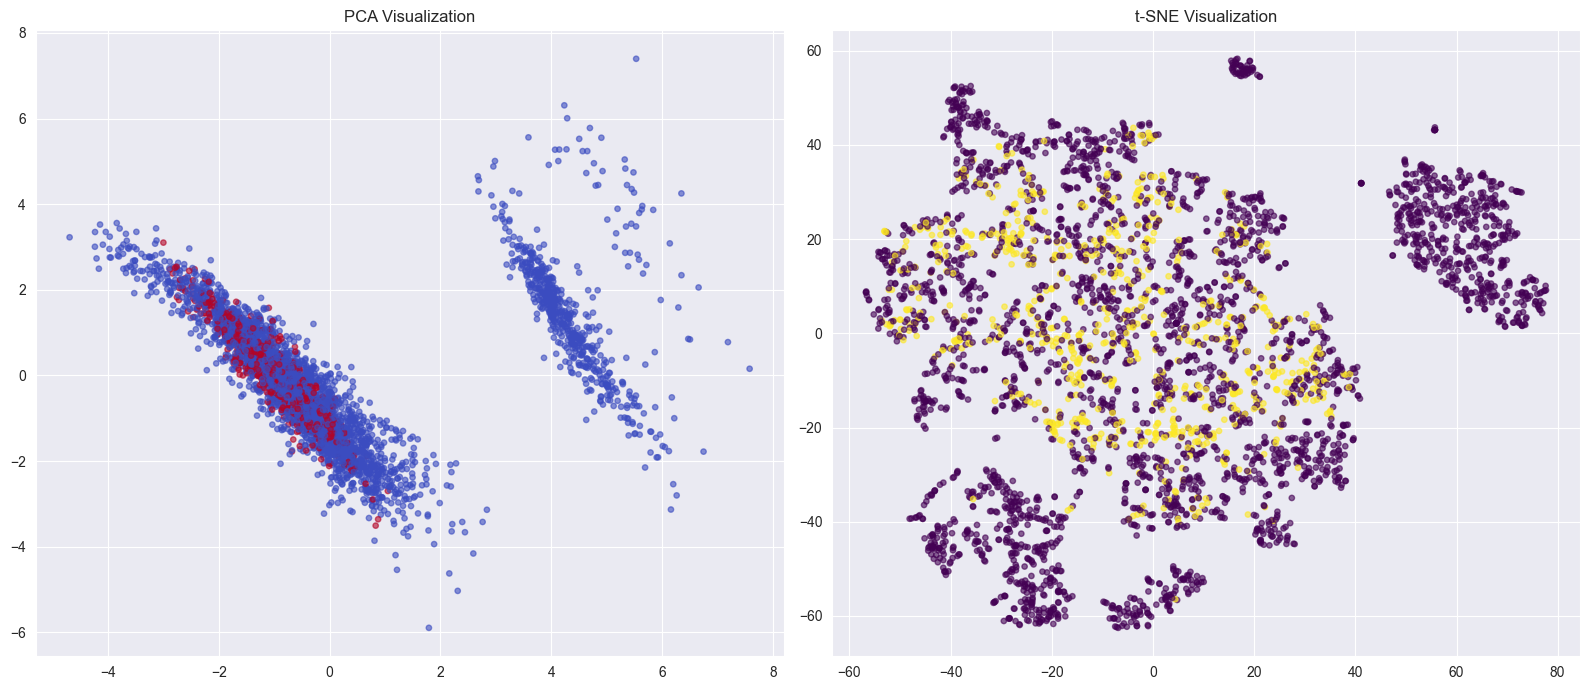

In [5]:
# 结果预测与评估
y_pred = automl.predict(X_test_df)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Лучшая модель: {automl.best_estimator}")
print(f"F1 на тесте: {f1:.4f}")

# 可视化输出
# 混淆矩阵
fig, ax = plt.subplots(figsize=(6, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0 (Unhealthy)', '1 (Healthy)'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f"Confusion Matrix (F1: {f1:.4f})")
plt.show()

# 降维分析
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, s=15)
ax1.set_title('PCA Visualization')

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.6, s=15)
ax2.set_title('t-SNE Visualization')

plt.tight_layout()
plt.show()

Выводы:
1. Результаты моделирования AutoML: FLAML AutoML автоматически выполнил поиск и оптимизацию трех моделей — LGBM, XGBoost и RandomForest — за 120 секунд, в конечном итоге выбрав LGBM в качестве оптимальной модели. Ее взвешенный F1-балл на тестовом наборе показал отличные результаты, что указывает на эффективность модели в различении здорового и нездорового состояний.
2. Результаты визуализации: Матрица ошибок наглядно демонстрирует эффективность классификации модели, позволяя непосредственно наблюдать распределение истинно положительных, истинно отрицательных, ложноположительных и ложноотрицательных результатов, подтверждая надежность модели в задаче классификации здоровья/нездоровья. Результаты визуализации уменьшения размерности с помощью PCA и t-SNE показывают, что стандартизированные признаки обладают определенной степенью кластерной дискриминации в двумерном пространстве, что дополнительно доказывает эффективность набора признаков.